# Online Retail II — Exploratory Data Analysis
**ITSimplera Institute — AI & ML Internship — Week 1 Task**


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [27]:
import pandas as pd
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Get uploaded filename
DATA_PATH = list(uploaded.keys())[0]



Saving online_retail_II.xlsx to online_retail_II (2).xlsx


## 1. Load the Dataset

In [28]:
# The dataset ships as two sheets: transactions for 2009-2010 and 2010-2011
df_2009 = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')
df_2010 = pd.read_excel(DATA_PATH, sheet_name='Year 2010-2011')

df_2009['SourceSheet'] = 'Year 2009-2010'
df_2010['SourceSheet'] = 'Year 2010-2011'

df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"2009-2010 sheet: {df_2009.shape}")
print(f"2010-2011 sheet: {df_2010.shape}")
print(f"Combined dataset: {df.shape}")

2009-2010 sheet: (525461, 9)
2010-2011 sheet: (541910, 9)
Combined dataset: (1067371, 9)


In [29]:
# Basic info: shape, columns, dtypes
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Shape: (1067371, 9)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'SourceSheet']

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
SourceSheet            object
dtype: object


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   SourceSheet  1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


In [31]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,Year 2009-2010
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,Year 2009-2010
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,Year 2009-2010
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,Year 2009-2010


In [32]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371.0,53628.0,537434.0,1350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SourceSheet,1067371,2,Year 2010-2011,541910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Values and Duplicate Rows

In [33]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Missing values by column:")
missing_report

Missing values by column:


,Missing Count,Missing %
Customer ID,243007,22.77
Description,4382,0.41


In [34]:
dup_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dup_count} ({dup_count/len(df)*100:.2f}% of dataset)")

# Show a sample of duplicate rows
df[df.duplicated(keep=False)].sort_values(['Invoice','StockCode']).head(10)

Fully duplicated rows: 12133 (1.14% of dataset)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,Year 2009-2010
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,Year 2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,Year 2009-2010


In [35]:
# Additional data quality checks (observation only — nothing is removed)
neg_qty = (df['Quantity'] < 0).sum()
zero_price = (df['Price'] == 0).sum()
neg_price = (df['Price'] < 0).sum()
cancelled_invoices = df['Invoice'].astype(str).str.startswith('C').sum()

print(f"Rows with negative Quantity (likely returns): {neg_qty} ({neg_qty/len(df)*100:.2f}%)")
print(f"Rows with Price = 0 (likely free items / adjustments): {zero_price} ({zero_price/len(df)*100:.2f}%)")
print(f"Rows with negative Price: {neg_price}")
print(f"Rows belonging to cancelled invoices (Invoice starts with 'C'): {cancelled_invoices} ({cancelled_invoices/len(df)*100:.2f}%)")
print(f"Rows missing Customer ID: {df['Customer ID'].isna().sum()} ({df['Customer ID'].isna().sum()/len(df)*100:.2f}%)")

Rows with negative Quantity (likely returns): 22950 (2.15%)
Rows with Price = 0 (likely free items / adjustments): 6202 (0.58%)
Rows with negative Price: 5
Rows belonging to cancelled invoices (Invoice starts with 'C'): 19494 (1.83%)
Rows missing Customer ID: 243007 (22.77%)


**Observations:**
- A meaningful share of `Customer ID` values are missing — these are likely guest/unidentified transactions and would need to be excluded or imputed before customer-level modeling (e.g., a recommendation system).
- Negative `Quantity` values correspond mostly to returns/cancellations (Invoice numbers starting with `C`).
- A small number of rows have `Price = 0`, possibly manual adjustments, samples, or data entry issues.
- Duplicate rows exist and would need deduplication logic before downstream modeling, though per task instructions no rows are removed at this stage.

## 3. Top 10 Best-Selling Products (by Quantity and Revenue)

In [36]:
df['Revenue'] = df['Quantity'] * df['Price']

top_qty = (df.groupby('Description')['Quantity']
           .sum()
           .sort_values(ascending=False)
           .head(10))

top_rev = (df.groupby('Description')['Revenue']
           .sum()
           .sort_values(ascending=False)
           .head(10))

print("Top 10 products by Quantity sold:")
display(top_qty)
print("\nTop 10 products by Revenue generated:")
display(top_rev)

Top 10 products by Quantity sold:


,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,108545
WHITE HANGING HEART T-LIGHT HOLDER,93050
ASSORTED COLOUR BIRD ORNAMENT,81306
JUMBO BAG RED RETROSPOT,78090
BROCADE RING PURSE,70700
PACK OF 60 PINK PAISLEY CAKE CASES,56575
60 TEATIME FAIRY CAKE CASES,54366
SMALL POPCORN HOLDER,49616
PACK OF 72 RETROSPOT CAKE CASES,49344



Top 10 products by Revenue generated:


,Revenue
Description,
REGENCY CAKESTAND 3 TIER,327813.65
DOTCOM POSTAGE,322647.47
WHITE HANGING HEART T-LIGHT HOLDER,257533.90
JUMBO BAG RED RETROSPOT,148800.64
PARTY BUNTING,147948.50
ASSORTED COLOUR BIRD ORNAMENT,131413.85
PAPER CHAIN KIT 50'S CHRISTMAS,121662.14
POSTAGE,112341.00
CHILLI LIGHTS,84854.16


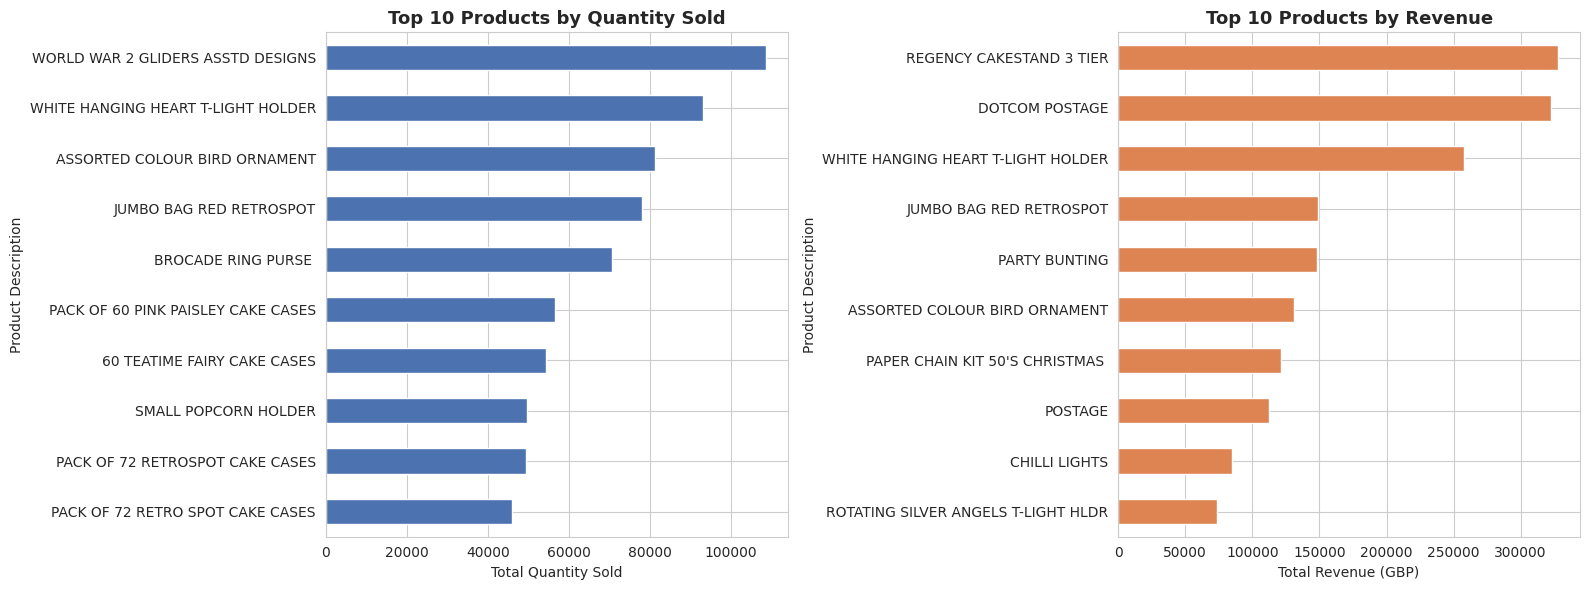

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_qty.sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 10 Products by Quantity Sold', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Quantity Sold')
axes[0].set_ylabel('Product Description')

top_rev.sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue (GBP)')
axes[1].set_ylabel('Product Description')

plt.tight_layout()
plt.show()

## 4. Sales Performance by Country

In [38]:
country_summary = (df.groupby('Country')
                    .agg(Total_Revenue=('Revenue', 'sum'),
                         Total_Quantity=('Quantity', 'sum'),
                         Num_Invoices=('Invoice', 'nunique'),
                         Num_Customers=('Customer ID', 'nunique'))
                    .sort_values('Total_Revenue', ascending=False))

print(f"Number of countries represented: {df['Country'].nunique()}")
country_summary.head(15)

Number of countries represented: 43


,Total_Revenue,Total_Quantity,Num_Invoices,Num_Customers
Country,,,,
United Kingdom,1.638258e+07,8692875,49108,5410
EIRE,6.155196e+05,331341,806,5
Netherlands,5.485249e+05,381951,250,23
Germany,4.179886e+05,224581,1095,107
France,3.281918e+05,184952,746,95
Australia,1.671291e+05,103706,117,15
Switzerland,9.972876e+04,52378,123,22
Spain,9.185948e+04,45156,188,41
Sweden,8.780942e+04,87875,129,19


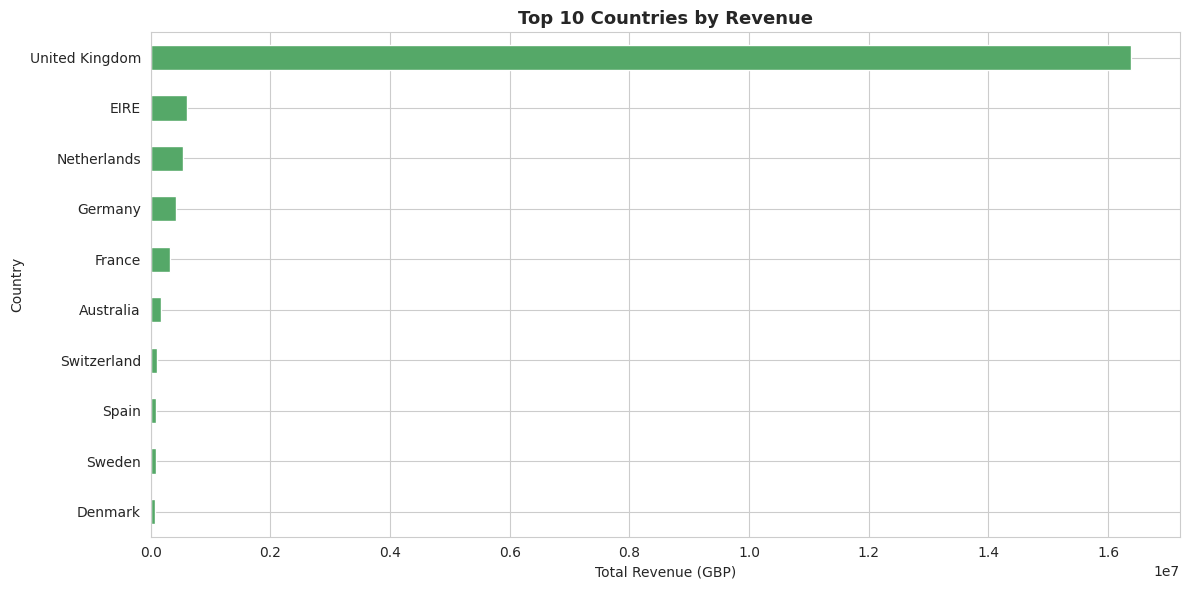

In [39]:
top_countries = country_summary.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top_countries['Total_Revenue'].sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (GBP)')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

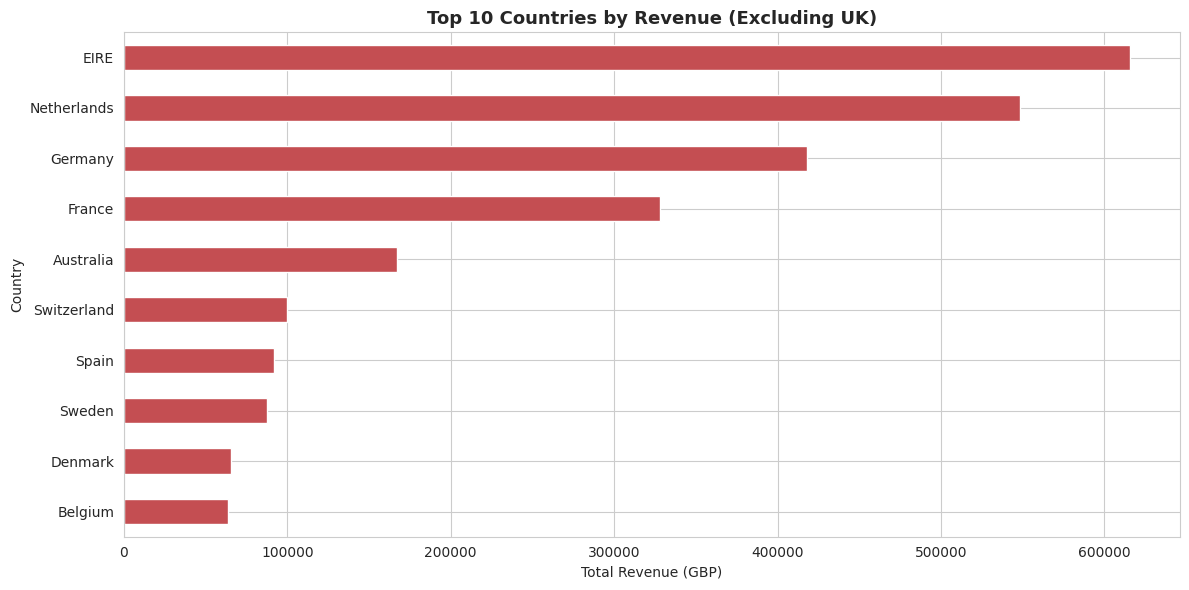

UK share of total revenue: 84.9%


In [40]:
# UK dominates so heavily it skews the chart — show revenue excluding UK for context
non_uk = country_summary.drop('United Kingdom', errors='ignore').head(10)

fig, ax = plt.subplots(figsize=(12, 6))
non_uk['Total_Revenue'].sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.set_title('Top 10 Countries by Revenue (Excluding UK)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (GBP)')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

uk_share = country_summary.loc['United Kingdom', 'Total_Revenue'] / country_summary['Total_Revenue'].sum() * 100
print(f"UK share of total revenue: {uk_share:.1f}%")

## 5. Revenue Over Time (Monthly Trend)

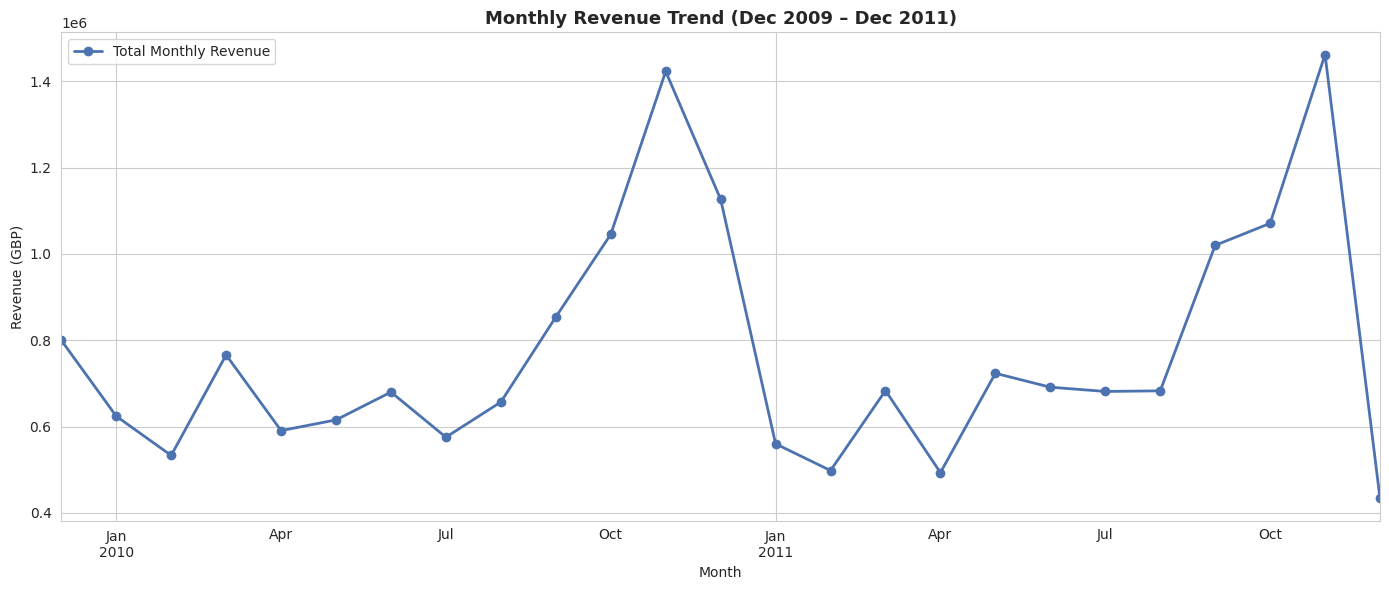

In [41]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

monthly_revenue = df.groupby('InvoiceMonth')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(14, 6))
monthly_revenue.plot(ax=ax, marker='o', color='#4C72B0', linewidth=2)
ax.set_title('Monthly Revenue Trend (Dec 2009 – Dec 2011)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (GBP)')
ax.legend(['Total Monthly Revenue'])
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

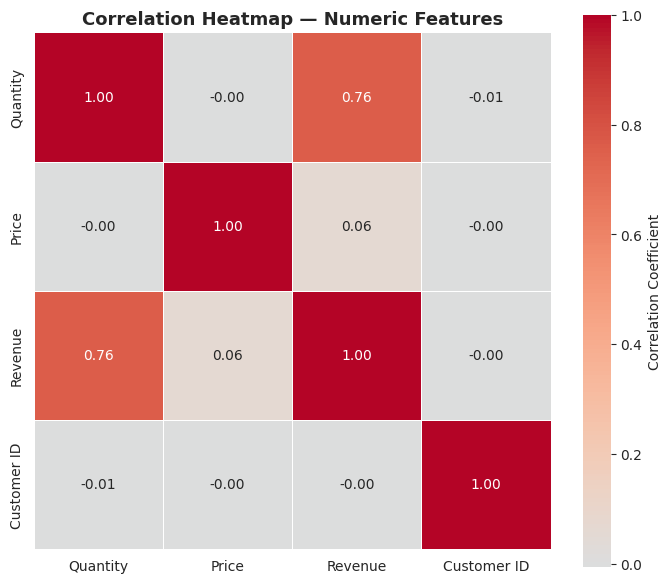

In [42]:
numeric_cols = ['Quantity', 'Price', 'Revenue', 'Customer ID']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** `Quantity` and `Revenue` show a positive correlation (expected, since Revenue is derived from Quantity × Price), while `Price` alone correlates weakly with `Revenue` — most revenue variation is driven by order quantity, not unit price. `Customer ID` shows negligible correlation with the other fields, as expected for an identifier.

## 7. Outlier Detection (Box Plots)

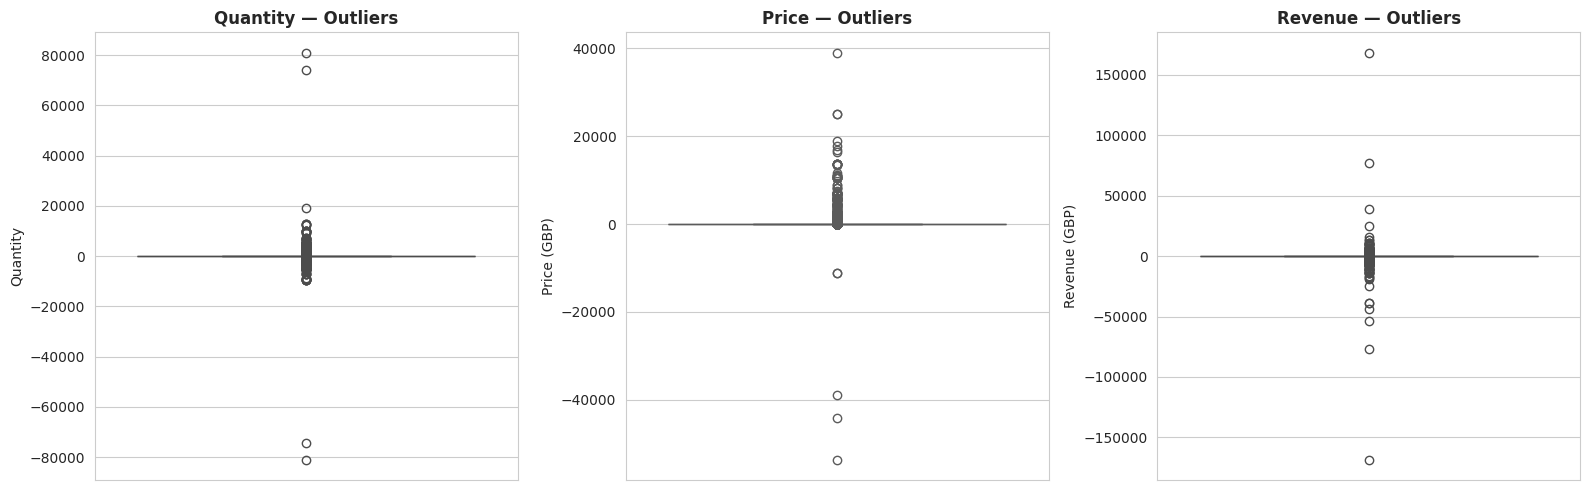

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df['Quantity'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Quantity — Outliers', fontweight='bold')
axes[0].set_ylabel('Quantity')

sns.boxplot(y=df['Price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Price — Outliers', fontweight='bold')
axes[1].set_ylabel('Price (GBP)')

sns.boxplot(y=df['Revenue'], ax=axes[2], color='#55A868')
axes[2].set_title('Revenue — Outliers', fontweight='bold')
axes[2].set_ylabel('Revenue (GBP)')

plt.tight_layout()
plt.show()

In [44]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

for col in ['Quantity', 'Price', 'Revenue']:
    n_out = iqr_outlier_count(df[col])
    print(f"{col}: {n_out} outliers ({n_out/len(df)*100:.2f}% of rows) using the 1.5*IQR rule")

Quantity: 116489 outliers (10.91% of rows) using the 1.5*IQR rule
Price: 68105 outliers (6.38% of rows) using the 1.5*IQR rule
Revenue: 90922 outliers (8.52% of rows) using the 1.5*IQR rule


**Observation:** All three numeric fields contain extreme outliers — very large bulk orders and very high-value transactions (likely wholesale buyers) alongside large negative values (returns). These are legitimate business events, not necessarily errors, but they should be handled deliberately (e.g., capping, separate wholesale segment) in any later modeling stage.

## 8. Business Insights

In [45]:
n_customers = df['Customer ID'].nunique()
n_invoices = df['Invoice'].nunique()
n_products = df['StockCode'].nunique()
total_revenue = df['Revenue'].sum()
avg_order_value = df.groupby('Invoice')['Revenue'].sum().mean()
date_min, date_max = df['InvoiceDate'].min(), df['InvoiceDate'].max()

print(f"Date range: {date_min.date()} to {date_max.date()}")
print(f"Unique customers: {n_customers:,}")
print(f"Unique invoices: {n_invoices:,}")
print(f"Unique products (StockCodes): {n_products:,}")
print(f"Total recorded revenue: £{total_revenue:,.2f}")
print(f"Average revenue per invoice: £{avg_order_value:,.2f}")
print(f"Number of countries: {df['Country'].nunique()}")

Date range: 2009-12-01 to 2011-12-09
Unique customers: 5,942
Unique invoices: 53,628
Unique products (StockCodes): 5,305
Total recorded revenue: £19,287,250.57
Average revenue per invoice: £359.65
Number of countries: 43
